# Mobile Phone Price Analysis and Data Cleaning
**Course:** WIH2001 Data Analytics  
**Assignment:** Individual Assignment  
**Dataset:** [Mobile Phone Price Prediction @ Kaggle](https://www.kaggle.com/datasets/dewangmoghe/mobile-phone-price-prediction/data)  
**Methodology:** CRISP-DM (Phase 1 - 3)  
**By:** Wan Muhammad Hazwan bin Wan Rozli - 23002102

## Overview
This notebook analyzes smartphone models to determine whether a device is fairly priced based on its technical specifications. Using the CRISP-DM methodology, we explore, understand, and preprocess the dataset as groundwork for price prediction.

In [1]:
!pip install kagglehub
!pip install missingno

In [2]:
import kagglehub
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

## 1) Dataset Selection

### 1.1 Dataset: Mobile Phone Price Prediction
**Source:** Kaggle : [Mobile Phone Price Prediction](https://www.kaggle.com/datasets/dewangmoghe/mobile-phone-price-prediction/data)  
**Records:** 1,370 rows  
**Attributes:** 18 columns  

### 1.2 Why This Dataset?
Smartphones are a part of everyday life, and as someone who is quite knowledgeable about mobile technology, I have noticed a recurring problem among consumers, many of my peers often end up purchasing overpriced smartphones that offer poor specifications relative to their cost.

This inspired me to take a data-driven approach to the problem. Rather than relying on brand reputation or marketing, this analysis uses actual device specifications such as RAM, battery, camera, processor, and storage to determine whether a smartphone is fairly priced or overpriced.

### 1.3 Does It Meet Requirements?
| Criteria | Requirement | This Dataset |
|---|---|---|
| Minimum Records | 500 |  1,370 records |
| Minimum Attributes | 5 |  18 attributes |

In [3]:
# Download latest version
path = kagglehub.dataset_download("dewangmoghe/mobile-phone-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\dewangmoghe\mobile-phone-price-prediction\versions\1


In [4]:
df = pd.read_csv(os.path.join(path, 'mobile_phone_price_prediction.csv'))
df.head(10)

,Unnamed: 0,Name,Rating,Spec_score,No_of_sim,Ram,Battery,Display,Camera,External_Memory,Android_version,Price,company,Inbuilt_memory,fast_charging,Screen_resolution,Processor,Processor_name
0,0,Samsung Galaxy F14 5G,4.65,68,"Dual Sim, 3G, 4G, 5G, VoLTE,",4 GB RAM,6000 mAh Battery,6.6 inches,50 MP + 2 MP Dual Rear &amp; 13 MP Front Camera,"Memory Card Supported, upto 1 TB",13,"9,999",Samsung,128 GB inbuilt,25W Fast Charging,2408 x 1080 px Display with Water Drop Notch,Octa Core Processor,Exynos 1330
1,1,Samsung Galaxy A11,4.20,63,"Dual Sim, 3G, 4G, VoLTE,",2 GB RAM,4000 mAh Battery,6.4 inches,13 MP + 5 MP + 2 MP Triple Rear &amp; 8 MP Fro...,"Memory Card Supported, upto 512 GB",10,"9,990",Samsung,32 GB inbuilt,15W Fast Charging,720 x 1560 px Display with Punch Hole,1.8 GHz Processor,Octa Core
2,2,Samsung Galaxy A13,4.30,75,"Dual Sim, 3G, 4G, VoLTE,",4 GB RAM,5000 mAh Battery,6.6 inches,50 MP Quad Rear &amp; 8 MP Front Camera,"Memory Card Supported, upto 1 TB",12,"11,999",Samsung,64 GB inbuilt,25W Fast Charging,1080 x 2408 px Display with Water Drop Notch,2 GHz Processor,Octa Core
3,3,Samsung Galaxy F23,4.10,73,"Dual Sim, 3G, 4G, VoLTE,",4 GB RAM,6000 mAh Battery,6.4 inches,48 MP Quad Rear &amp; 13 MP Front Camera,"Memory Card Supported, upto 1 TB",12,"11,999",Samsung,64 GB inbuilt,NaN,720 x 1600 px,Octa Core,Helio G88
4,4,Samsung Galaxy A03s (4GB RAM + 64GB),4.10,69,"Dual Sim, 3G, 4G, VoLTE,",4 GB RAM,5000 mAh Battery,6.5 inches,13 MP + 2 MP + 2 MP Triple Rear &amp; 5 MP Fro...,"Memory Card Supported, upto 1 TB",11,"11,999",Samsung,64 GB inbuilt,15W Fast Charging,720 x 1600 px Display with Water Drop Notch,Octa Core,Helio P35
5,5,Samsung Galaxy M13 5G,4.40,75,"Dual Sim, 3G, 4G, 5G, VoLTE,",6 GB RAM,5000 mAh Battery,6.5 inches,50 MP + 2 MP Dual Rear &amp; 5 MP Front Camera,"Memory Card Supported, upto 1 TB",12,"11,990",Samsung,128 GB inbuilt,15W Fast Charging,720 x 1600 px,Octa Core,Dimensity 700
6,6,Samsung Galaxy M21 2021,4.10,76,"Dual Sim, 3G, 4G, VoLTE,",4 GB RAM,6000 mAh Battery,6.4 inches,48 MP + 8 MP + 5 MP Triple Rear &amp; 20 MP Fr...,"Memory Card Supported, upto 512 GB",11,"11,990",Samsung,64 GB inbuilt,15W Fast Charging,1080 x 2340 px Display with Water Drop Notch,Octa Core,Exynos 9611
7,7,Samsung Galaxy A12,4.10,71,"Dual Sim, 3G, 4G, VoLTE,",4 GB RAM,5000 mAh Battery,6.5 inches,48 MP Quad Rear &amp; 8 MP Front Camera,Memory Card Supported,10,"11,990",Samsung,64 GB inbuilt,15W Fast Charging,720 x 1560 px Display with Water Drop Notch,Octa Core,Helio P35
8,8,Samsung Galaxy A14 5G,4.05,75,"Dual Sim, 3G, 4G, 5G, VoLTE,",4 GB RAM,5000 mAh Battery,6.6 inches,50 MP + 2 MP + 2 MP Triple Rear &amp; 13 MP Fr...,"Memory Card Supported, upto 1 TB",13,"11,599",Samsung,64 GB inbuilt,15W Fast Charging,1080 x 2408 px,Octa Core,Exynos 1330
9,9,Samsung Galaxy M13,4.50,75,"Dual Sim, 3G, 4G, VoLTE,",6 GB RAM,6000 mAh Battery,6.6 inches,50 MP + 5 MP + 2 MP Triple Rear &amp; 8 MP Fro...,"Memory Card Supported, upto 1 TB",12,"12,298",Samsung,128 GB inbuilt,15W Fast Charging,1080 x 2400 px Display with Water Drop Notch,Octa Core,Exynos 850


## 2) Business Understanding

### 2.1 Problem Statement
The smartphone market is highly competitive, with hundreds of models across a wide range of price points. Consumers and retailers often struggle to determine whether a phone is fairly priced given its specifications. This analysis aims to identify which features(e.g., RAM, battery, camera) most significantly influence smartphone prices, and to understand the pricing patterns acrossdifferent market segments.


### 2.2 Objectives
1. Explore and understand the distribution of smartphone prices.
2. Identify key features (attributes) that correlate with price.
3. Detect any anomalies or inconsistencies in smartphone pricing.
4. Prepare the dataset for future predictive modelling.

### 2.3 Impact
- Consumers: Make informed purchasing decisions based on specs vs price.
- Retailers & Manufacturers: Benchmark pricing strategies against competitors.
- Analysts: Understand market segmentation (budget, mid-range, flagship).

## 3) Data Understanding

Determine row x column

In [5]:
df.shape

(1370, 18)

First look at the dataset

In [6]:
df.head()

,Unnamed: 0,Name,Rating,Spec_score,No_of_sim,Ram,Battery,Display,Camera,External_Memory,Android_version,Price,company,Inbuilt_memory,fast_charging,Screen_resolution,Processor,Processor_name
0,0,Samsung Galaxy F14 5G,4.65,68,"Dual Sim, 3G, 4G, 5G, VoLTE,",4 GB RAM,6000 mAh Battery,6.6 inches,50 MP + 2 MP Dual Rear &amp; 13 MP Front Camera,"Memory Card Supported, upto 1 TB",13,"9,999",Samsung,128 GB inbuilt,25W Fast Charging,2408 x 1080 px Display with Water Drop Notch,Octa Core Processor,Exynos 1330
1,1,Samsung Galaxy A11,4.20,63,"Dual Sim, 3G, 4G, VoLTE,",2 GB RAM,4000 mAh Battery,6.4 inches,13 MP + 5 MP + 2 MP Triple Rear &amp; 8 MP Fro...,"Memory Card Supported, upto 512 GB",10,"9,990",Samsung,32 GB inbuilt,15W Fast Charging,720 x 1560 px Display with Punch Hole,1.8 GHz Processor,Octa Core
2,2,Samsung Galaxy A13,4.30,75,"Dual Sim, 3G, 4G, VoLTE,",4 GB RAM,5000 mAh Battery,6.6 inches,50 MP Quad Rear &amp; 8 MP Front Camera,"Memory Card Supported, upto 1 TB",12,"11,999",Samsung,64 GB inbuilt,25W Fast Charging,1080 x 2408 px Display with Water Drop Notch,2 GHz Processor,Octa Core
3,3,Samsung Galaxy F23,4.10,73,"Dual Sim, 3G, 4G, VoLTE,",4 GB RAM,6000 mAh Battery,6.4 inches,48 MP Quad Rear &amp; 13 MP Front Camera,"Memory Card Supported, upto 1 TB",12,"11,999",Samsung,64 GB inbuilt,NaN,720 x 1600 px,Octa Core,Helio G88
4,4,Samsung Galaxy A03s (4GB RAM + 64GB),4.10,69,"Dual Sim, 3G, 4G, VoLTE,",4 GB RAM,5000 mAh Battery,6.5 inches,13 MP + 2 MP + 2 MP Triple Rear &amp; 5 MP Fro...,"Memory Card Supported, upto 1 TB",11,"11,999",Samsung,64 GB inbuilt,15W Fast Charging,720 x 1600 px Display with Water Drop Notch,Octa Core,Helio P35


Before proceeding, lowercasing all string value can help with duplicates of the same name. For example "Poco" is just duplicate of "POCO" or "poco".

In [7]:
# lowercase all of the 'object' data
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1370 entries, 0 to 1369
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1370 non-null   int64  
 1   Name               1370 non-null   object 
 2   Rating             1370 non-null   float64
 3   Spec_score         1370 non-null   int64  
 4   No_of_sim          1370 non-null   object 
 5   Ram                1370 non-null   object 
 6   Battery            1370 non-null   object 
 7   Display            1370 non-null   object 
 8   Camera             1370 non-null   object 
 9   External_Memory    1370 non-null   object 
 10  Android_version    927 non-null    object 
 11  Price              1370 non-null   object 
 12  company            1370 non-null   object 
 13  Inbuilt_memory     1351 non-null   object 
 14  fast_charging      1281 non-null   object 
 15  Screen_resolution  1368 non-null   object 
 16  Processor          1342 

In [10]:
# null value count for each attribute
df.isnull().sum()

Unnamed: 0             0
Name                   0
Rating                 0
Spec_score             0
No_of_sim              0
Ram                    0
Battery                0
Display                0
Camera                 0
External_Memory        0
Android_version      443
Price                  0
company                0
Inbuilt_memory        19
fast_charging         89
Screen_resolution      2
Processor             28
Processor_name         0
dtype: int64

In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [13]:
# drop meaningless column
df = df.drop(columns=['Unnamed: 0']) 

In [14]:
df.describe(include='all')

,Name,Rating,Spec_score,No_of_sim,Ram,Battery,Display,Camera,External_Memory,Android_version,Price,company,Inbuilt_memory,fast_charging,Screen_resolution,Processor,Processor_name
count,1370,1370.000000,1370.000000,1370,1370,1370,1370,1370,1370,927,1370,1370,1351,1281,1368,1342,1370
unique,1334,NaN,NaN,9,16,79,89,347,85,23,449,22,10,38,141,14,249
top,realme narzo n55 (6gb ram + 128gb),NaN,NaN,"dual sim, 3g, 4g, 5g, volte,",8 gb ram,5000 mah battery,6.7 inches,50 mp + 2 mp dual rear &amp; 8 mp front camera,"memory card supported, upto 1 tb",13,"29,990",vivo,128 gb inbuilt,18w fast charging,1080 x 2400 px,octa core,snapdragon 8+ gen1
freq,3,NaN,NaN,818,528,752,158,81,233,280,37,186,644,157,357,1237,58
mean,NaN,4.374416,80.234307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.230176,8.373922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,3.750000,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,4.150000,75.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,4.400000,82.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,4.550000,86.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There's not much of possible visualisation, since the data is mostly not numerical.

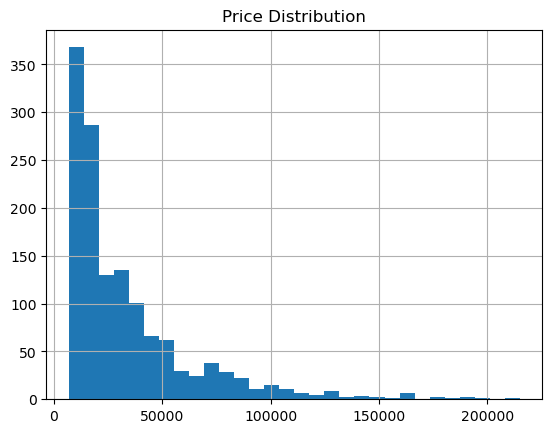

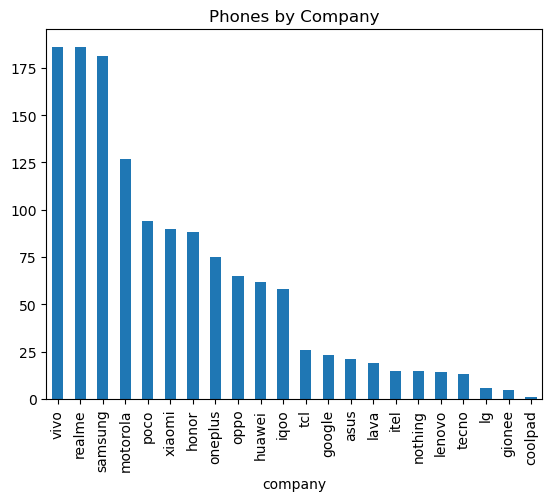

In [15]:
# Price distribution
df['Price'] = df['Price'].str.replace(',', '').astype(float)
df['Price'].hist(bins=30)
plt.title('Price Distribution')
plt.show()

# Company count
df['company'].value_counts().plot(kind='bar')
plt.title('Phones by Company')
plt.show()

Printing all possible unique value count, to check of the data richness and dirtiness.

In [16]:
pd.set_option('display.max_colwidth', None)

for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts())
    print("-" * 40)


Name (1334 unique):
Name
realme narzo n55 (6gb ram + 128gb)    3
vivo v30 pro (12gb ram + 512gb)       2
vivo s19 pro                          2
vivo v25 pro (12gb ram + 256gb)       2
vivo v30 5g                           2
                                     ..
poco c31 (4gb ram + 64gb)             1
poco c65 (6gb ram + 128gb)            1
poco c50 (3gb ram + 32gb)             1
poco c55                              1
tcl trifold                           1
Name: count, Length: 1334, dtype: int64
----------------------------------------

No_of_sim (9 unique):
No_of_sim
dual sim, 3g, 4g, 5g, volte,            818
dual sim, 3g, 4g, volte,                419
dual sim, 3g, 4g, 5g, volte, vo5g,       91
single sim, 3g, 4g, 5g, volte,           20
dual sim, 3g, 4g,                        13
single sim, 3g, 4g, volte,                6
no sim supported,                         1
single sim, 3g, 4g, 5g, volte, vo5g,      1
dual sim, 3g, volte,                      1
Name: count, dtype: int6

## 4) Data Preprocessing

Check for weird value which does not contain the most important element of the column, based on the uniqueness table on previous cell. This step will determine how to clean the data later on.

In [17]:
#check for value which doesn't contain 'x' substring
keywords = {
    'Camera': 'mp',
    'Ram': 'ram',
    'Battery': 'mah',
    'Display': 'inches',
    'External_Memory': 'memory',
    'Inbuilt_memory': 'gb',
    'fast_charging': 'charging',
    'Processor': 'core',
    'Screen_resolution': 'px'
}

for col, keyword in keywords.items():
    weird = df[~df[col].str.contains(keyword, case=False, na=False)][col]
    if len(weird) > 0:
        print(f"\n{col} — {len(weird)} weird rows:")
        print(weird.value_counts())
        print("-" * 40)


Camera — 80 weird rows:
Camera
foldable display, dual display                               69
dual display                                                  8
6.5 inches, 1080 x 2400 px, 90 hz display with punch hole     1
foldable display                                              1
memory card (hybrid)                                          1
Name: count, dtype: int64
----------------------------------------

Ram — 20 weird rows:
Ram
256 gb inbuilt                               8
128 gb inbuilt                               7
512 gb inbuilt                               3
helio g90t                                   1
6000 mah battery with 22.5w fast charging    1
Name: count, dtype: int64
----------------------------------------

Battery — 2 weird rows:
Battery
6 gb ram, 64 gb inbuilt               1
6.75 inches, 720 x 1600 px display    1
Name: count, dtype: int64
----------------------------------------

Display — 2 weird rows:
Display
4300 mah battery with 30w fast charging 

Cleaning the "Camera" column. Splitting the value by the ampersand(&) into intermediate column and trace the number after splitting. Make the number as float-type. Drop the original and temporary column after that. Check how the data looks and the nulls count.

In [18]:
# --Fixing Camera--

if 'Camera' in df.columns:
    # Split into rear and front
    df['Rear_Camera'] = df['Camera'].str.split('&amp;').str[0]
    df['Front_Camera'] = df['Camera'].str.split('&amp;').str[1]

    # Extract highest MP from rear
    df['Rear_Camera_MP'] = df['Rear_Camera'].str.extractall(r'(\d+)').astype(float).groupby(level=0).max()

    # Extract front MP
    df['Front_Camera_MP'] = df['Front_Camera'].str.extract(r'(\d+)').astype(float)

    # Drop original and intermediate columns
    df = df.drop(columns=['Camera', 'Rear_Camera', 'Front_Camera'])
    
    print("Camera split done successfully!")
else:
    print("Camera splitting already done in a previous run, skipping...")
    
print("Rear_Camera_MP value counts:")
print(df['Rear_Camera_MP'].value_counts().head(10))
print("\nFront_Camera_MP value counts:")
print(df['Front_Camera_MP'].value_counts().head(10))
print("\nNulls:")
print(df[['Rear_Camera_MP', 'Front_Camera_MP']].isnull().sum())
print("\nSample:")
print(df[['Rear_Camera_MP', 'Front_Camera_MP']].head(10))

Camera split done successfully!
Rear_Camera_MP value counts:
Rear_Camera_MP
50.0     659
64.0     213
13.0     111
108.0    106
48.0      77
200.0     35
8.0       29
16.0      20
12.0      15
100.0      7
Name: count, dtype: int64

Front_Camera_MP value counts:
Front_Camera_MP
16.0    359
8.0     280
32.0    245
5.0     124
13.0     95
50.0     73
12.0     29
60.0     29
20.0     18
10.0     17
Name: count, dtype: int64

Nulls:
Rear_Camera_MP     79
Front_Camera_MP    82
dtype: int64

Sample:
   Rear_Camera_MP  Front_Camera_MP
0            50.0             13.0
1            13.0              8.0
2            50.0              8.0
3            48.0             13.0
4            13.0              5.0
5            50.0              5.0
6            48.0             20.0
7            48.0              8.0
8            50.0             13.0
9            50.0              8.0


We see that there's some nulls for the Rear_Camera_MP and Front_Camera_MP. I choose to drop them mainly because camera MPs have big range, and guessing it will simply means that inaccuracies occur. However, it's a low % of data loss.

In [19]:
# drop nulls for camera because guessing camera specs leads to inaccuracies. 6% data loss.
df = df.dropna(subset=['Rear_Camera_MP', 'Front_Camera_MP'])

print("Rows remaining:", len(df))
print("Nulls remaining:")
print(df[['Rear_Camera_MP', 'Front_Camera_MP']].isnull().sum())

Rows remaining: 1288
Nulls remaining:
Rear_Camera_MP     0
Front_Camera_MP    0
dtype: int64


Cleaning procedure for RAM column. From the weird value table, I choose 'gb inbuilt', 'mah', 'helio', 'snapdragon', 'ghz' as the invalid ram value. If the string contains any of them, drop. Dropping them is chosen, since the % of the data loss is very low.

In [20]:
# --Fixing Ram--
if df['Ram'].dtype == 'object':
    # Remove invalid rows first
    invalid_ram = ['gb inbuilt', 'mah', 'helio', 'snapdragon', 'ghz']
    df = df[~df['Ram'].str.contains('|'.join(invalid_ram), na=False)]
    
    # Extract numbers only
    df['Ram'] = df['Ram'].str.extract(r'(\d+\.?\d*)').astype(float)
    
else:
    print("Ram already cleaned in previous run, skipping...")

print(df['Ram'].value_counts())
print("\nNulls:", df['Ram'].isnull().sum())
print("Rows remaining:", len(df))

Ram
8.0     496
4.0     253
6.0     213
12.0    208
3.0      38
16.0     33
2.0      21
18.0      4
24.0      2
1.0       1
1.5       1
Name: count, dtype: int64

Nulls: 0
Rows remaining: 1270


The same concept as RAM column cleaning is applied here. 'gb ram', 'inches', 'display' is chosen as invalid Battery value. Null checking is a must.

In [21]:
#--Fixing Battery--
if df['Battery'].dtype == 'object':
    # Remove invalid rows first
    invalid_battery = ['gb ram', 'inches', 'display']
    df = df[~df['Battery'].str.contains('|'.join(invalid_battery), na=False)]
    
    # Extract numbers only
    df['Battery'] = df['Battery'].str.extract(r'(\d+)').astype(float)

else:
    print("Battery already cleaned in previous run, skipping...")

print(df['Battery'].value_counts().head(10))
print("\nNulls:", df['Battery'].isnull().sum())
print("Rows remaining:", len(df))

Battery
5000.0    727
4500.0    108
6000.0    100
4000.0     34
5500.0     32
4800.0     31
4600.0     27
4700.0     20
5100.0     19
4200.0     14
Name: count, dtype: int64

Nulls: 0
Rows remaining: 1270


The same concept as Battery and RAM column as well, but any string with substring of 'mah', 'mp', 'camera' will considered as invalid.

In [22]:
#--Fixing Display--
if df['Display'].dtype == 'object':
    # Remove invalid rows first
    invalid_display = ['mah', 'mp', 'camera']
    df = df[~df['Display'].str.contains('|'.join(invalid_display), na=False)]
    
    # Extract numbers only
    df['Display'] = df['Display'].str.extract(r'(\d+\.?\d*)').astype(float)
    
else:
    print("Display already cleaned in previous run, skipping...")

print(df['Display'].value_counts().head(10))
print("\nNulls:", df['Display'].isnull().sum())
print("Rows remaining:", len(df))

Display
6.70    147
6.67    146
6.78    135
6.50    122
6.60     94
6.80     51
6.74     50
6.56     49
6.72     49
6.58     36
Name: count, dtype: int64

Nulls: 0
Rows remaining: 1270


Binary encoding is used. Lambda make into use here. If 'not supported' or 'memory card' was found, then it is 0 or 1 respectively. Other than those will be considered as weird value and it will turned into null.

In [23]:
# --Fixing External Memory--
# 1 = memory card supported, 0 = not supported
df['External_Memory'] = df['External_Memory'].apply(
    lambda x: 0 if isinstance(x, str) and 'not supported' in x else
              1 if isinstance(x, str) and 'memory card' in x else
              None  # weird values become null
)

print(df['External_Memory'].value_counts())
print("Nulls:", df['External_Memory'].isnull().sum())

External_Memory
1.0    746
0.0    142
Name: count, dtype: int64
Nulls: 382


As we can see there's a lot of nulls here, so simply dropping them will be a huge data loss. So, I choose to fill the value with mode, because its a binary encoding. Filling with mean or median does not make sense.

In [24]:
# Fill nulls with mode, then convert to int
df['External_Memory'] = df['External_Memory'].fillna(df['External_Memory'].mode()[0])
df['External_Memory'] = df['External_Memory'].astype(int)

# Verify
print(df['External_Memory'].value_counts())
print("Nulls remaining:", df['External_Memory'].isnull().sum())

External_Memory
1    1128
0     142
Name: count, dtype: int64
Nulls remaining: 0


For the inbuilt memory column, the same procedure as Battery, RAM, and Display was used. 'octa core', 'quad core', 'processor' is considered invalid. An extra step of converting TB into GB is applied.

In [25]:
if df['Inbuilt_memory'].dtype == 'object':
    # Remove invalid rows first
    invalid_inbuilt = ['octa core', 'quad core', 'processor']
    df = df[~df['Inbuilt_memory'].str.contains('|'.join(invalid_inbuilt), na=False)]
    
    # Convert TB to GB before extracting
    df['Inbuilt_memory'] = df['Inbuilt_memory'].apply(
        lambda x: '1024 gb inbuilt' if 'tb' in str(x).lower() else x
    )
    
    # Extract numbers only
    df['Inbuilt_memory'] = df['Inbuilt_memory'].str.extract(r'(\d+)').astype(float)

else:
    print("Inbuilt_memory already cleaned in previous run, skipping...")

print(df['Inbuilt_memory'].value_counts())
print("\nNulls:", df['Inbuilt_memory'].isnull().sum())
print("Rows remaining:", len(df))

Inbuilt_memory
128.0     625
256.0     360
64.0      183
32.0       48
512.0      46
1024.0      3
16.0        3
258.0       1
8.0         1
Name: count, dtype: int64

Nulls: 0
Rows remaining: 1270


For fast_charging, the same concept is used, with the difference of there's some missing values in this column. Median is used; because, mean is heavily affected by extreme value, and mode is not valid(18w) because 18w is old/budget phones. Modern phone is higher. 

In [26]:
if df['fast_charging'].dtype == 'object':
    # Remove invalid rows first
    invalid_fc = ['water drop notch', 'display', 'inches']
    df = df[~df['fast_charging'].str.contains('|'.join(invalid_fc), na=False)]
    
    # Extract numbers only
    df['fast_charging'] = df['fast_charging'].str.extract(r'(\d+)').astype(float)

    # fill with company median
    df['fast_charging'] = df.groupby('company')['fast_charging'].transform(lambda x: x.fillna(x.median()))

    # Step fallback to overall median for any remaining nulls
    df['fast_charging'] = df['fast_charging'].fillna(df['fast_charging'].median())

else:
    print("fast_charging already cleaned in previous run, skipping...")

print(df['fast_charging'].value_counts().head(10))
print("\nNulls:", df['fast_charging'].isnull().sum())
print("Rows remaining:", len(df))

fast_charging
18.0     168
33.0     163
25.0     106
67.0      93
44.0      73
80.0      72
45.0      68
100.0     64
120.0     63
15.0      59
Name: count, dtype: int64

Nulls: 0
Rows remaining: 1270


Cleaning processor column. Uniqueness of the data is counted for each possible value. 

In [27]:
#--Fixing Processor--
print(df['Processor'].value_counts())
print("\nNulls:", df['Processor'].isnull().sum())

Processor
octa core              1154
octa core processor      68
quad core                 8
1.6 ghz processor         3
deca core                 3
2 ghz processor           2
nine-cores                2
nine core                 2
nine cores                2
1.8 ghz processor         1
1.3 ghz processor         1
2.3 ghz processor         1
Name: count, dtype: int64

Nulls: 23


As we can see, the data shows some duplicate. 'octa core' and 'octa core processor' is the same. Same case goes to 'nine core', 'nine-cores', and 'nine cores'. Other than that, I planned to turn them into categorical(Ordinal) data with the 'octa core', 'nine core', 'deca core' and 'others' as values. Then the NaN was filled with the mode, which is 'octa core' since it is extremely dominant compared to other category.

In [28]:
if df['Processor'].dtype == 'object':
    # Standardize naming
    df['Processor'] = df['Processor'].replace({
        'octa core processor': 'octa core',
        'nine-cores': 'nine core',
        'nine cores': 'nine core',
        'deca core processor': 'deca core',
        '1.6 ghz processor': 'other',
        '1.8 ghz processor': 'other',
        '1.3 ghz processor': 'other',
        '2.3 ghz processor': 'other',
        '2 ghz processor': 'other',
    })

    # fill NaN with octa-core, since octa core is extremely dominant
    df['Processor'] = df['Processor'].fillna('octa core')

else:
    print("Processor already cleaned in previous run, skipping...")

print(df['Processor'].value_counts())
print("\nNulls:", df['Processor'].isnull().sum())

Processor
octa core    1245
other           8
quad core       8
nine core       6
deca core       3
Name: count, dtype: int64

Nulls: 0


Turning No_of_sim into more meaningful data. I choose the highest generation of network instead of listing them in unordered manner. 5G will be 3, 4G will be 2, 3G will be 1, and no sim will be 0. It will turn into ordinal data.

In [29]:
def get_highest_connection(val):
    if pd.isnull(val):
        return None
    val = val.lower()
    if '5g' in val:
        return 3
    elif '4g' in val:
        return 2
    elif '3g' in val:
        return 1
    else:
        return 0

df['No_of_sim'] = df['No_of_sim'].apply(get_highest_connection)

print(df['No_of_sim'].value_counts())
print('\nNulls:',df['No_of_sim'].isnull().sum())

No_of_sim
3    854
2    415
0      1
Name: count, dtype: int64

Nulls: 0


Fixing the "Screen_resolution" column, by splitting the a * b px into two different column of width and height column. 

In [30]:
#--Fixing Screen Resolution--
if 'Screen_resolution' in df.columns:
    # Extract both numbers
    df['Resolution_width'] = df['Screen_resolution'].str.extract(r'(\d+)\s*x').astype(float)
    df['Resolution_height'] = df['Screen_resolution'].str.extract(r'x\s*(\d+)').astype(float)

    # Drop original Screen_resolution
    df = df.drop(columns=['Screen_resolution'])

    df['Resolution_width'] = df['Resolution_width'].fillna(df['Resolution_width'].median())
    df['Resolution_height'] = df['Resolution_height'].fillna(df['Resolution_height'].median())

else:
    print("Already done in previous run, skipping...")
    
print(df[['Resolution_width', 'Resolution_height']].head(10))
print("\nNulls:")
print(df[['Resolution_width', 'Resolution_height']].isnull().sum())

   Resolution_width  Resolution_height
0            2408.0             1080.0
1             720.0             1560.0
2            1080.0             2408.0
3             720.0             1600.0
4             720.0             1600.0
5             720.0             1600.0
6            1080.0             2340.0
7             720.0             1560.0
8            1080.0             2408.0
9            1080.0             2400.0

Nulls:
Resolution_width     0
Resolution_height    0
dtype: int64


In [31]:
# Now that we fixed all weird value, its time to check how the dataset looks overall

print("=" * 25)
print("Final Data Validation")
print("=" * 25)

print(f"\nShape: {df.shape}")

print("\nData Types:")
print(df.dtypes)

print("\nNull Values:")
null_check = df.isnull().sum()
print(null_check[null_check > 0] if null_check.sum() > 0 else "No nulls.")

print("\nDuplicates:", df.duplicated().sum())

print("\nNumerical Summary:")
print(df.describe())

Final Data Validation

Shape: (1270, 19)

Data Types:
Name                  object
Rating               float64
Spec_score             int64
No_of_sim              int64
Ram                  float64
Battery              float64
Display              float64
External_Memory        int64
Android_version       object
Price                float64
company               object
Inbuilt_memory       float64
fast_charging        float64
Processor             object
Processor_name        object
Rear_Camera_MP       float64
Front_Camera_MP      float64
Resolution_width     float64
Resolution_height    float64
dtype: object

Null Values:
Android_version    384
dtype: int64

Duplicates: 0

Numerical Summary:
            Rating   Spec_score    No_of_sim          Ram       Battery  \
count  1270.000000  1270.000000  1270.000000  1270.000000   1270.000000   
mean      4.375394    79.800787     2.670866     7.527953   4957.418898   
std       0.230613     8.184852     0.475086     3.171765    522.716100

drop android_version because there's not much meaning and it has a lot of missing values.

In [32]:
# drop android_version
df = df.drop(columns=['Android_version'])
print("Shape:", df.shape)

Shape: (1270, 18)


For verification purpose

In [33]:
df.head(15)

,Name,Rating,Spec_score,No_of_sim,Ram,Battery,Display,External_Memory,Price,company,Inbuilt_memory,fast_charging,Processor,Processor_name,Rear_Camera_MP,Front_Camera_MP,Resolution_width,Resolution_height
0,samsung galaxy f14 5g,4.65,68,3,4.0,6000.0,6.6,1,9999.0,samsung,128.0,25.0,octa core,exynos 1330,50.0,13.0,2408.0,1080.0
1,samsung galaxy a11,4.20,63,2,2.0,4000.0,6.4,1,9990.0,samsung,32.0,15.0,other,octa core,13.0,8.0,720.0,1560.0
2,samsung galaxy a13,4.30,75,2,4.0,5000.0,6.6,1,11999.0,samsung,64.0,25.0,other,octa core,50.0,8.0,1080.0,2408.0
3,samsung galaxy f23,4.10,73,2,4.0,6000.0,6.4,1,11999.0,samsung,64.0,25.0,octa core,helio g88,48.0,13.0,720.0,1600.0
4,samsung galaxy a03s (4gb ram + 64gb),4.10,69,2,4.0,5000.0,6.5,1,11999.0,samsung,64.0,15.0,octa core,helio p35,13.0,5.0,720.0,1600.0
5,samsung galaxy m13 5g,4.40,75,3,6.0,5000.0,6.5,1,11990.0,samsung,128.0,15.0,octa core,dimensity 700,50.0,5.0,720.0,1600.0
6,samsung galaxy m21 2021,4.10,76,2,4.0,6000.0,6.4,1,11990.0,samsung,64.0,15.0,octa core,exynos 9611,48.0,20.0,1080.0,2340.0
7,samsung galaxy a12,4.10,71,2,4.0,5000.0,6.5,1,11990.0,samsung,64.0,15.0,octa core,helio p35,48.0,8.0,720.0,1560.0
8,samsung galaxy a14 5g,4.05,75,3,4.0,5000.0,6.6,1,11599.0,samsung,64.0,15.0,octa core,exynos 1330,50.0,13.0,1080.0,2408.0
9,samsung galaxy m13,4.50,75,2,6.0,6000.0,6.6,1,12298.0,samsung,128.0,15.0,octa core,exynos 850,50.0,8.0,1080.0,2400.0


### Handling Outlier

Before applying any outlier treatment, boxplots and density plots were generated for all numerical columns to visually inspect the data distribution. The boxplot shows where most values are concentrated and highlights any extreme values as dots outside the whiskers. The density plot shows the overall shape of the data. This helps in making a more informed decision on which columns actually need outlier treatment rather than blindly applying statistical methods to every column.

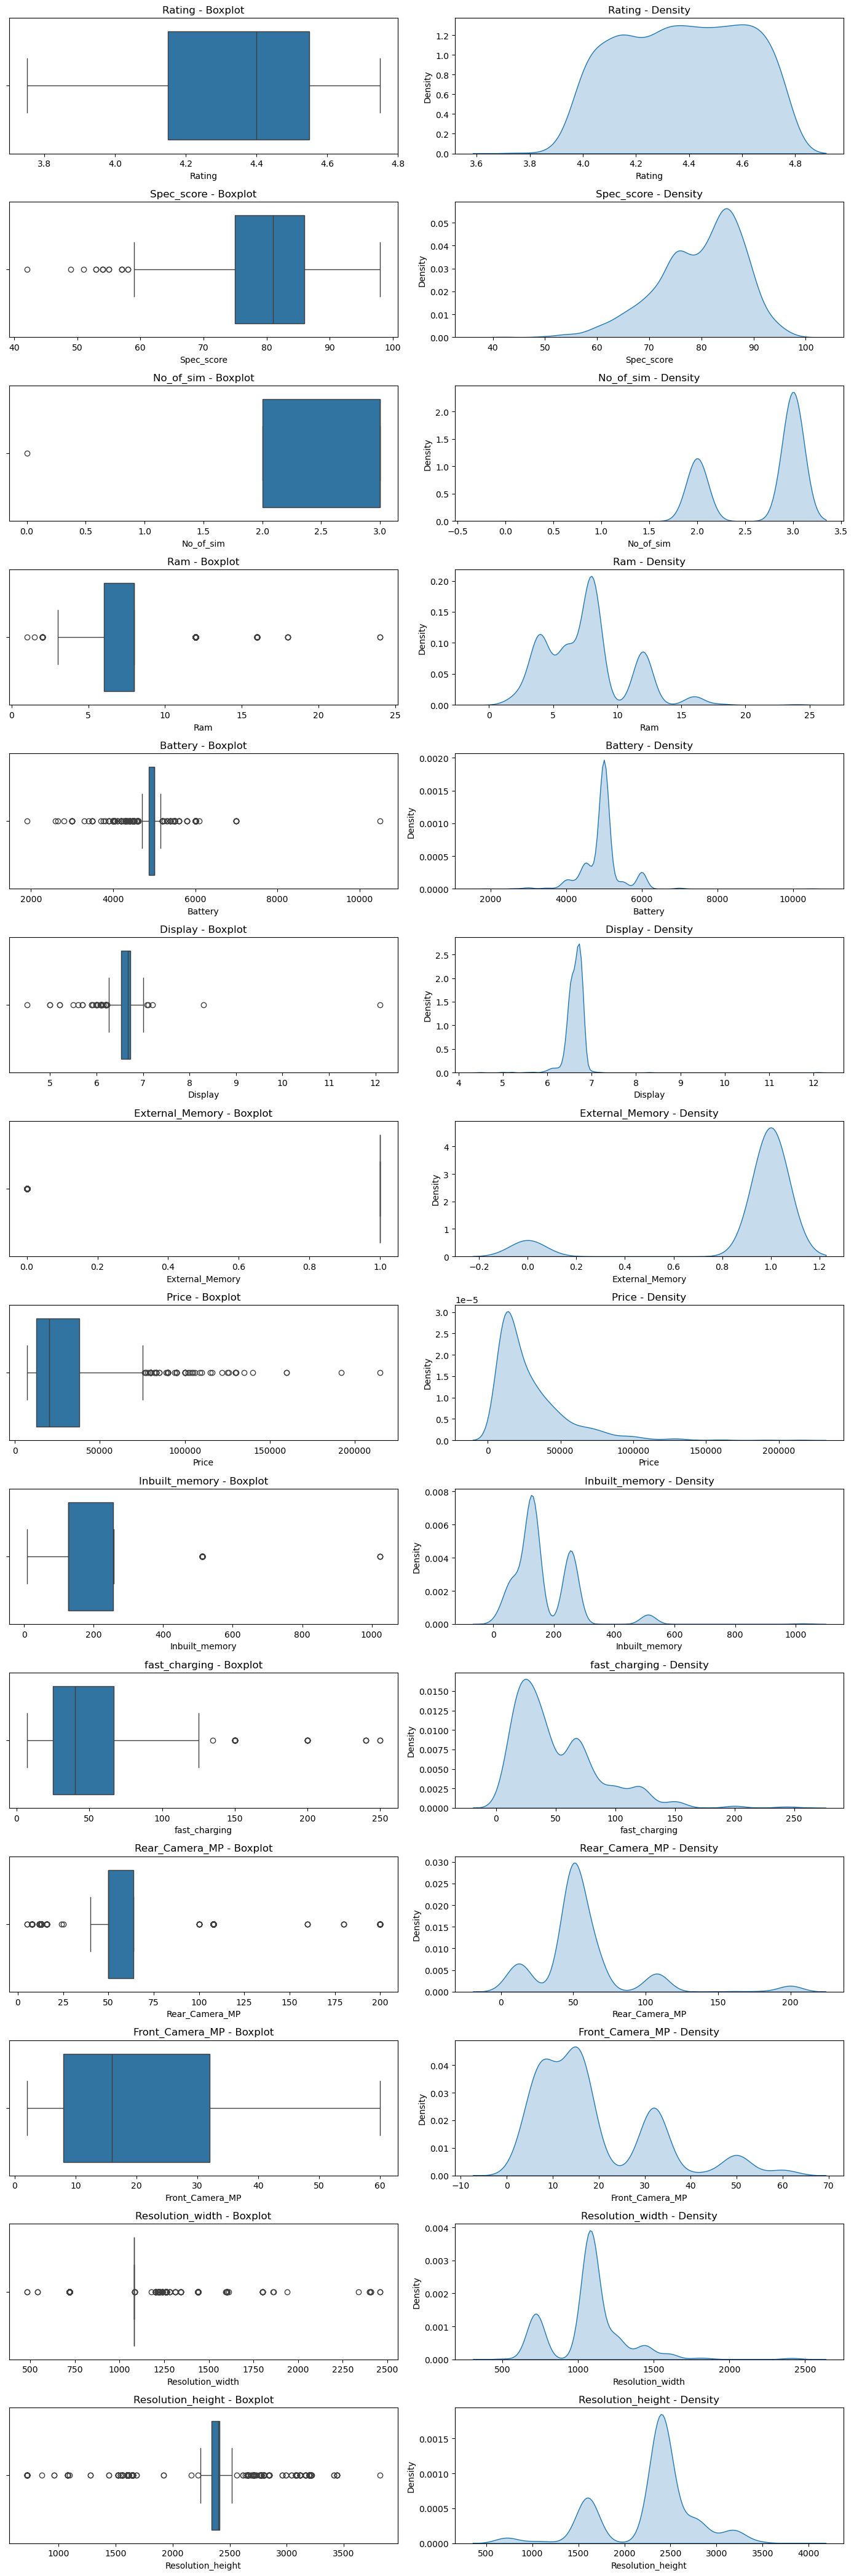

In [34]:
numerical_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, len(numerical_cols) * 3))

for i, col in enumerate(numerical_cols):
    # Boxplot on the left
    sns.boxplot(x=df[col], ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Boxplot')
    
    # Density plot on the right
    sns.kdeplot(df[col], ax=axes[i, 1], fill=True)
    axes[i, 1].set_title(f'{col} - Density')

plt.tight_layout()
plt.show()

It is very noticable that there's an outlier of extreme value for battery, display and price which doesnt make sense for the phone to be that way.

In [35]:
print("Battery > 9000:")
print(df[df['Battery'] > 9000][['Name', 'Battery', 'Price', 'Display']])

print("\nDisplay > 8:")
print(df[df['Display'] > 8][['Name', 'Display', 'Battery', 'Price']])

print("\nPrice > 175000:")
print(df[df['Price'] > 175000][['Name', 'Price', 'company', 'Display']])

Battery > 9000:
                Name  Battery    Price  Display
538  poco pad tablet  10500.0  29990.0     12.1

Display > 8:
                     Name  Display  Battery     Price
538       poco pad tablet     12.1  10500.0   29990.0
648  google pixel notepad      8.3   5003.0  125990.0

Price > 175000:
                                  Name     Price company  Display
1279  huawei mate 30 rs porsche design  214990.0  huawei     6.53
1287  huawei mate 40 rs porsche design  191999.0  huawei     6.76


In [36]:
df = df[df['Battery'] <= 9000]
print("Rows remaining:", len(df))

df = df[df['Price'] <= 175000]
print("Rows remaining:", len(df))

df = df[df['Display'] <= 8]
print("Rows remaining:", len(df))

Rows remaining: 1269
Rows remaining: 1267
Rows remaining: 1266


Now that the data is cleaned and is in numerical value for most of the column, we can finally do proper correlation heatmap. Most importantly, data is ready to be used for the next CRISP-DM step.

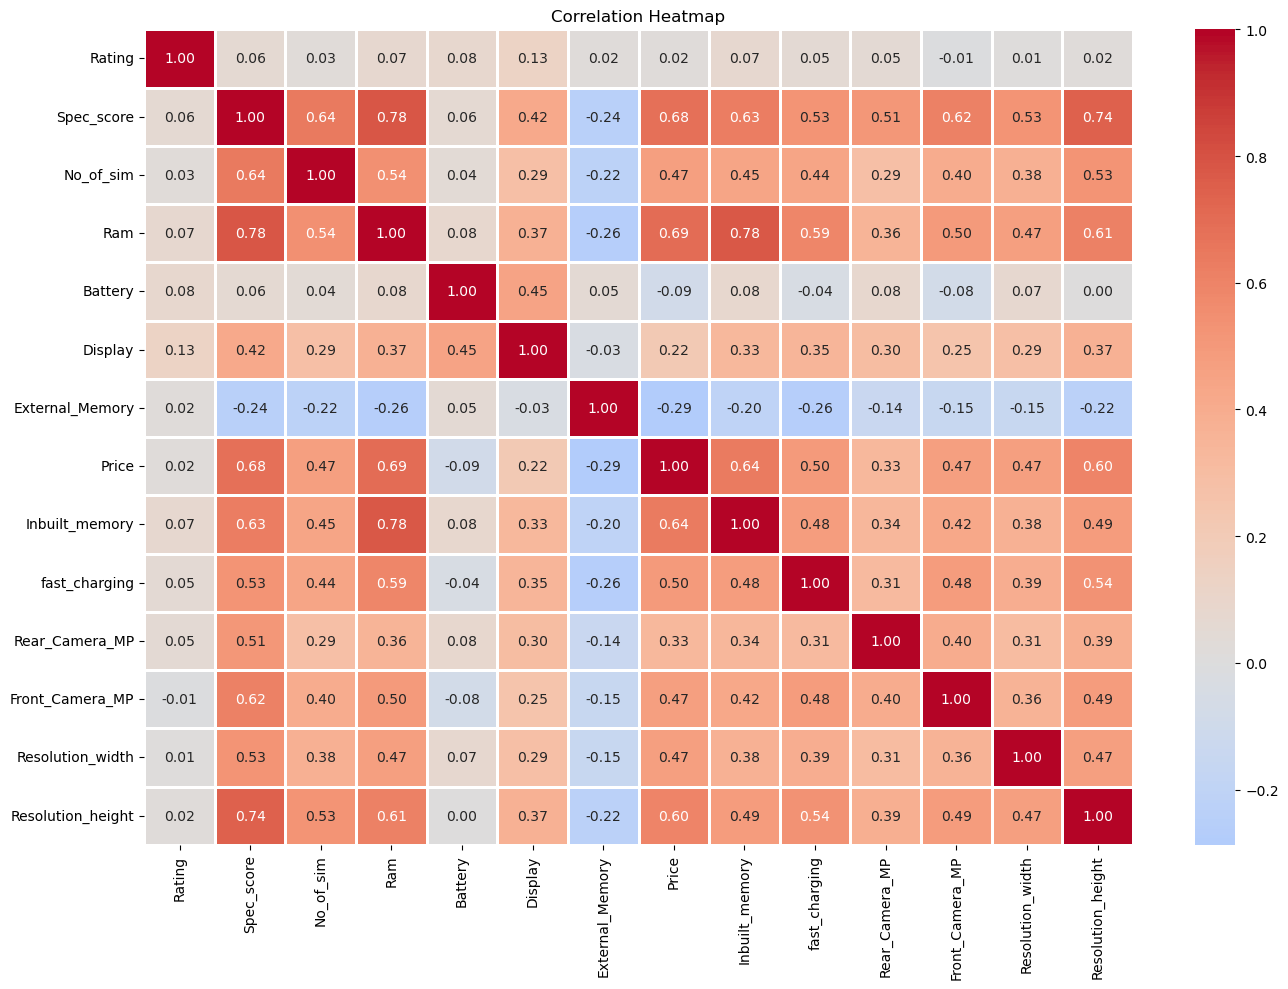

In [37]:
# Select numerical columns only
numerical_df = df.select_dtypes(include='number')

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(numerical_df.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            linewidths=1)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

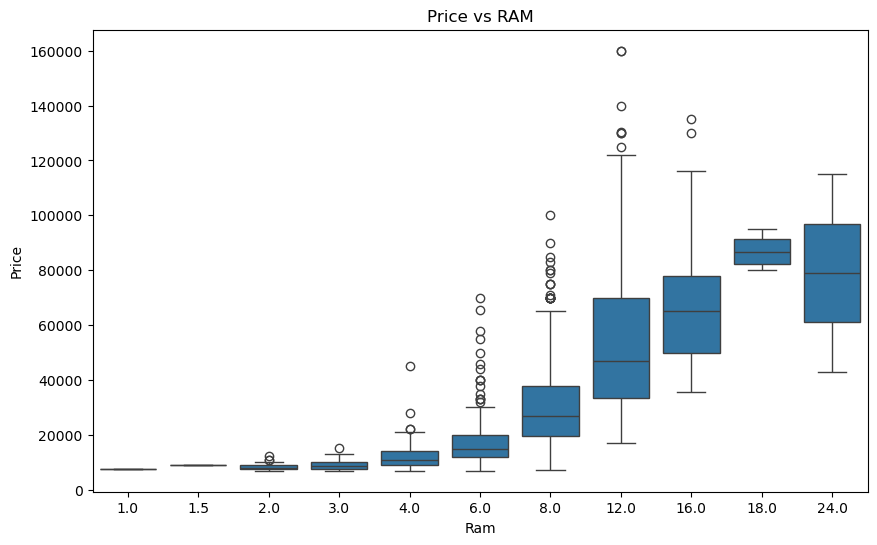

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Ram', y='Price')
plt.title('Price vs RAM')
plt.show()

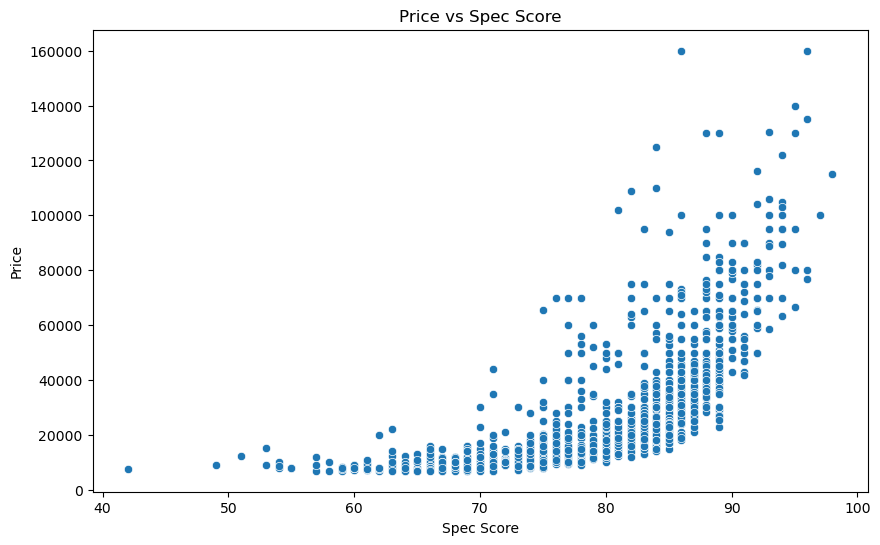

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Spec_score', y='Price')
plt.title('Price vs Spec Score')
plt.xlabel('Spec Score')
plt.ylabel('Price')
plt.show()

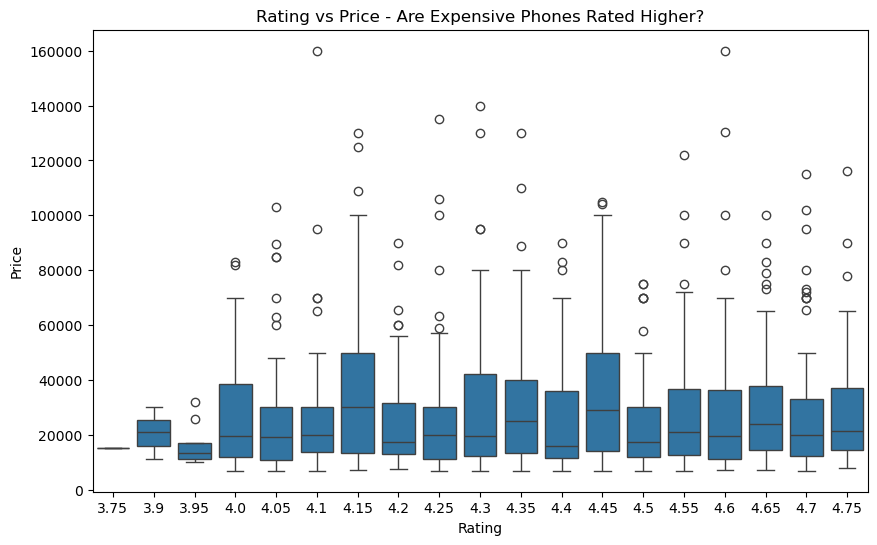

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Rating', y='Price')
plt.title('Rating vs Price - Are Expensive Phones Rated Higher?')
plt.show()